# Join parts with a beam

In this tutorial we build a chain of three pillbox cells from one cell, solve the cell
once with the beam, and join the three copies with the beam. We check the chain's beam
impedance against the same three cells solved in one piece. Then we take a cell solved
earlier in a project of its own, without a beam, import it three times, and get the
same chain.

**Prerequisites:** [Add a beam to a solved cavity](beam_on_solved_cavity.ipynb),
[Repeat a section](../multi_part/repeated_sections.ipynb) and
[Reuse a solved project](../multi_part/reuse_projects.ipynb).

## 1. Repeat a cell with the beam

### 1.1 Add one cell, three times

A pillbox cell of radius 100 mm and length 100 mm, with 30 mm of beam pipe (radius
40 mm) on each side; `n=3` repeats it.

In [1]:
from cavsim3d.core.em_project import EMProject

cell = dict(n_cells=1, dims=[100, 100, 40, 0, 30], beampipe="both")

proj = EMProject(name="pillbox_chain", base_dir="./simulations", overwrite=True)
proj.create_primitive("pillbox", name="cell", n=3, **cell)
print(proj.geometry.describe_layout())

✅ Creating new project 'pillbox_chain' at simulations\pillbox_chain


Main axis: Z (default). Parts follow the list order along +Z:
  1. cell x3: z = [-0.08, 0.08] m
Mesh strategy: coupled (each unique part meshed and solved on its own, joined through port modes; repeated: cell (n=3))


A repeated part is coupled: the cell is meshed and solved once, and its copies are
joined through the modes of the ports that face each other.

### 1.2 Add the beam and mesh

In [2]:
proj.add_beam("beam")
proj.generate_mesh(maxh=0.014)

Main axis: Z (default). Parts follow the list order along +Z:
  1. cell x3: z = [-0.08, 0.08] m
Mesh strategy: coupled (each unique part meshed and solved on its own, joined through port modes; repeated: cell (n=3))


The beam's position is given in the frame of the first cell; every next cell sits with
the face it is joined by centred on the face it joins.

### 1.3 Solve the cell

Three port modes per port: TE11 in two polarisations, and TM01. At the joins, 30 mm
from each cavity, the beam's TM01 field has not died away yet, so it is carried
across.

In [3]:
import time

cfg = dict(fmin=1.05, fmax=1.17, nsamples=7, nportmodes=3, order=3)
t0 = time.time()
res = proj.fds.solve(**cfg)
print(f"solved in {time.time() - t0:.0f} s")

✅ Mesh strategy: coupled (repeated: cell (n=3)): each unique part is solved on its own and the parts are joined through their port modes.


✅ Solve plan:
  cell  geometry             compute   full-order solve, 7 samples, with the beam



Structure Topology
  Type: Single structure
  Domains (1): ['vacuum']
  Ports (2): ['port1', 'port2']
  Mesh elements: 5412
✅ Section 'cell': full-order solve with the beam


Assembling Matrices...


Solving port eigenmodes...


Calculating Port Eigenmodes...


	port1 mode 0: TE_11 (cos), kc=46.0296, sigma=+1
	port1 mode 1: TE_11 (sin), kc=46.0296, sigma=+1
	port1 mode 2: TM_01, kc=60.1206, sigma=+1
	port2 mode 0: TE_11 (cos), kc=46.0296, sigma=+1


	port2 mode 1: TE_11 (sin), kc=46.0296, sigma=+1
	port2 mode 2: TM_01, kc=60.1206, sigma=+1
Port eigenmodes complete: 6 total modes



FDS Solve: 1.0500 - 1.1700 GHz, 7 samples


Global Coupled Solve


  Auto solver: 108111 unknowns, a factorisation needs about 0.7 GB of 32.7 GB free -> 'direct'


  
Coupled solve complete: 2 external ports in 22.36s


✅ Netlist FOM stage complete: 1 unique section(s) for 3 instance(s) with the beam: join them with fds.foms.concatenate()


solved in 24 s


The solve plan has one line, `cell ... compute ... with the beam`: the cell is solved
once, with the beam where it runs through it.

### 1.4 Join the copies

In [4]:
chain = proj.fds.foms.concatenate()
print("S~ columns:", chain.tilde_labels[1])

✅ Joined 3 part copies through their generalised scattering matrices (beam): 6 external port mode(s), 7 frequencies (those of the full-order solve).


S~ columns: ['1(1)', '1(2)', '1(3)', '2(1)', '2(2)', '2(3)', 'b(1)']


`foms.concatenate()` joins the three copies through their generalised scattering
matrices: the waves leaving one face enter the next, and a copy further along the axis
sees the beam later, with the phase of its position. The joined model has the six
port modes at the two ends of the chain and the beam.

## 2. Check against the cells in one piece

### 2.1 Solve the three cells as one mesh

Three parts, each added once, are glued into one mesh; `per_domain=False` solves it in
one piece.

In [5]:
whole = EMProject(name="pillbox_chain_whole", base_dir="./simulations", overwrite=True)
for name in ("c1", "c2", "c3"):
    whole.create_primitive("pillbox", name=name, **cell)
whole.add_beam("beam")
whole.generate_mesh(maxh=0.014)
t0 = time.time()
res = whole.fds.solve(**cfg, per_domain=False)
print(f"solved in {time.time() - t0:.0f} s")

✅ Creating new project 'pillbox_chain_whole' at simulations\pillbox_chain_whole


Main axis: Z (default). Parts follow the list order along +Z:
  1. c1: z = [-0.08, 0.08] m
  2. c2: z = [0.08, 0.24] m
  3. c3: z = [0.24, 0.4] m
Mesh strategy: glued (one conformal mesh of all parts; all parts are geometry, each used once)



Assembly domain-material mapping:


  c1: ['c1/vacuum']
  c2: ['c2/vacuum']
  c3: ['c3/vacuum']
Port naming complete:
  Total ports: 4
  External ports: 2
  Interface ports: 2



Structure Topology
  Type: Compound structure
  Domains (3): ['c1', 'c2', 'c3']
  Ports (4): ['port1', 'port2', 'port3', 'port4']
  Mesh elements: 14046
  External Ports (2): ['port1', 'port4']
  Internal Ports (2): ['port2', 'port3']

  Domain-Port Mapping:
    c1: ['port1 (input)', 'port2 (internal)']
    c2: ['port2 (internal)', 'port3 (internal)']
    c3: ['port3 (internal)', 'port4 (output)']



Assembling Matrices...


Solving port eigenmodes...


Calculating Port Eigenmodes...


	port1 mode 0: TE_11 (cos), kc=46.0296, sigma=+1
	port1 mode 1: TE_11 (sin), kc=46.0296, sigma=+1
	port1 mode 2: TM_01, kc=60.1206, sigma=+1


	port2 mode 0: TE_11 (cos), kc=46.0296, sigma=+1
	port2 mode 1: TE_11 (sin), kc=46.0296, sigma=+1
	port2 mode 2: TM_01, kc=60.1206, sigma=+1


	port3 mode 0: TE_11 (cos), kc=46.0296, sigma=+1
	port3 mode 1: TE_11 (sin), kc=46.0296, sigma=+1
	port3 mode 2: TM_01, kc=60.1206, sigma=+1


	port4 mode 0: TE_11 (cos), kc=46.0296, sigma=+1
	port4 mode 1: TE_11 (sin), kc=46.0296, sigma=+1
	port4 mode 2: TM_01, kc=60.1206, sigma=+1
Port eigenmodes complete: 12 total modes



FDS Solve: 1.0500 - 1.1700 GHz, 7 samples


Global Coupled Solve


  Auto solver: 282714 unknowns, a factorisation needs about 2.8 GB of 30.8 GB free -> 'direct'


  
Coupled solve complete: 2 external ports in 45.86s


solved in 49 s


### 2.2 Compare the beam impedance

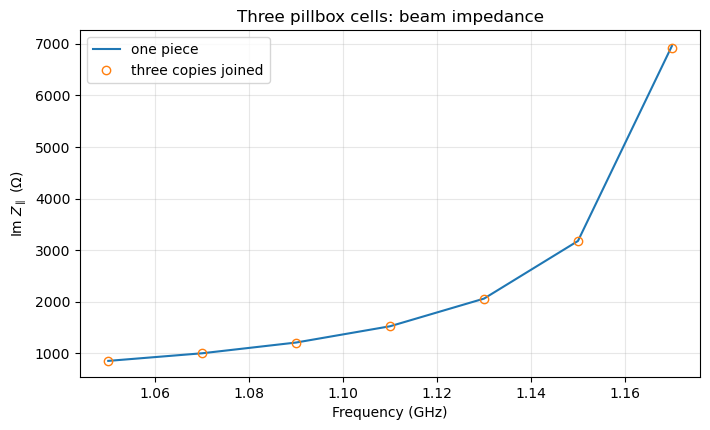

relative difference: median 2.2e-03, largest 5.0e-03
largest |Re Z_par|: one piece 0.02 Ohm, joined 0.43 Ohm


In [6]:
import matplotlib.pyplot as plt
import numpy as np

f = chain.frequencies
z_chain = chain.beam_impedance()
z_whole = whole.fds.fom.beam_impedance()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(f / 1e9, z_whole.imag, label="one piece")
ax.plot(f / 1e9, z_chain.imag, lw=0, marker="o", mfc="none", label="three copies joined")
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel(r"Im $Z_\parallel$ ($\Omega$)")
ax.set_title("Three pillbox cells: beam impedance")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

rel = np.abs(z_chain - z_whole) / np.abs(z_whole)
print(f"relative difference: median {np.median(rel):.1e}, largest {rel.max():.1e}")
print(f"largest |Re Z_par|: one piece {np.abs(z_whole.real).max():.2f} Ohm, "
      f"joined {np.abs(z_chain.real).max():.2f} Ohm")

The three copies joined at their ports give the beam impedance of the three cells in one
piece: the two agree within 0.5 % (median 0.2 %), the difference between two meshes. The
real parts are zero up to the discretisation, at most 0.02 Ω in one piece and 0.43 Ω
joined against an imaginary part of up to 6900 Ω: below the cut-off nothing is lost. The
impedance rises towards the TM010 resonance of the cells, just above the band.

## 3. Use a cell solved in another project

### 3.1 Solve one cell on its own, without a beam

A project of its own, as a colleague might have made it: the same cell, the same
sweep, no beam.

In [7]:
single = EMProject(name="pillbox_cell", base_dir="./simulations", overwrite=True)
single.create_primitive("pillbox", name="cell", **cell)
single.generate_mesh(maxh=0.014, curve_order=4)
res = single.fds.solve(**cfg)

✅ Creating new project 'pillbox_cell' at simulations\pillbox_cell



Structure Topology
  Type: Single structure
  Domains (1): ['vacuum']
  Ports (2): ['port1', 'port2']
  Mesh elements: 5412



Assembling Matrices...


Solving port eigenmodes...


Calculating Port Eigenmodes...


	port1 mode 0: TE_11 (cos), kc=46.0296, sigma=+1


	port1 mode 1: TE_11 (sin), kc=46.0296, sigma=+1
	port1 mode 2: TM_01, kc=60.1206, sigma=+1
	port2 mode 0: TE_11 (cos), kc=46.0296, sigma=+1


	port2 mode 1: TE_11 (sin), kc=46.0296, sigma=+1


	port2 mode 2: TM_01, kc=60.1206, sigma=+1
Port eigenmodes complete: 6 total modes



FDS Solve: 1.0500 - 1.1700 GHz, 7 samples


Global Coupled Solve


  Auto solver: 108111 unknowns, a factorisation needs about 0.7 GB of 30.8 GB free -> 'direct'


  
Coupled solve complete: 2 external ports in 17.73s


### 3.2 Import it three times and add the beam

In [8]:
imported = EMProject(name="pillbox_chain_imported", base_dir="./simulations", overwrite=True)
imported.import_project("./simulations/pillbox_cell", name="cell", n=3)
imported.add_beam("beam")
res = imported.fds.solve(**cfg)

✅ Creating new project 'pillbox_chain_imported' at simulations\pillbox_chain_imported


✅ Mesh strategy: coupled (imported: cell; repeated: cell (n=3)): each unique part is solved on its own and the parts are joined through their port modes.


✅ Solve plan:
  cell  imported (reference) reuse     its full-order results; beam columns computed here from its port solutions



Structure Topology
  Type: Single structure
  Domains (1): ['vacuum']
  Ports (2): ['port1', 'port2']
  Mesh elements: 5412

Structure Topology
  Type: Single structure
  Domains (1): ['vacuum']
  Ports (2): ['port1', 'port2']
  Mesh elements: 5412


Restored PortEigenmodeSolver with 2 ports, 6 total modes
FrequencyDomainSolver state loaded from simulations\pillbox_cell\fds
✅ Section 'cell': beam columns


✅ Beam added to solved port results: solving the beam columns only (the port results are kept).


  Auto solver: 108111 unknowns, a factorisation needs about 0.7 GB of 30.5 GB free -> 'direct'


  Beam columns: 17.16s


✅ Netlist FOM stage complete: 1 unique section(s) for 3 instance(s) with the beam: join them with fds.foms.concatenate()


The solve plan says *reuse ... beam columns computed here from its port solutions*:
the port results of the imported cell are used as they are, and the beam's columns are
computed in this project, from the port solutions stored in `pillbox_cell`. That
project is read, never written.

### 3.3 Join and compare

In [9]:
z_imported = imported.fds.foms.concatenate().beam_impedance()
print(f"largest difference from section 1: {np.abs(z_imported - z_chain).max():.1e} Ohm")

✅ Joined 3 part copies through their generalised scattering matrices (beam): 6 external port mode(s), 7 frequencies (those of the full-order solve).


largest difference from section 1: 4.3e-11 Ohm


The chain built from the imported cell is the chain of section 1, to 4e-11 Ω: the same
cell, the same port solutions, and beam columns computed the same way.

## What we did

We solved one pillbox cell with a beam and joined three copies of it, checked the chain
against the three cells solved in one piece, and built the same chain from a cell that
had been solved elsewhere without a beam.

**Next:** [Beam impedance of the TESLA cavity](tesla_beam_impedance.ipynb).

**Background:** [Beam excitation](../../theory/beam.md), §9.9 for joining parts with
the beam, and [Parts, joins and netlists](../../explanation/parts_and_joins.md).